# YouTube Analysis

## Importing & cleaning

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import statsmodels.api as sm
import scipy.stats as stats

In [2]:
# import data, see columns and first few rows
youtube = pd.read_csv('data/youtube_data.csv')
youtube

,video_id,title,description,published_date,channel_id,channel_title,tags,category_id,view_count,like_count,comment_count,duration,thumbnail
0,gsJAlLOFBv0,TINY Tech That Actually Works,No description available,2025-05-02T17:37:10Z,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,"['tiny', 'tech', 'gadgets', 'small', 'miniature']",28,8962092.0,243350.0,515.0,PT57S,https://i.ytimg.com/vi/gsJAlLOFBv0/default.jpg
1,ypicIkaiViM,AI & future of workforce: Andrew Yang on how t...,"Andrew Yang, Forward Party co-chair and former...",2025-06-18T12:39:53Z,UCrp_UI8XtuYfpiqluWLD7Lw,CNBC Television,"['Squawk Box U.S.', 'CNBC', 'business news', '...",25,289626.0,3393.0,1240.0,PT7M50S,https://i.ytimg.com/vi/ypicIkaiViM/default.jpg
2,1Nef8LPO-jo,5 ILLEGAL gadgets that will get you ARRESTED,#shorts #technology \n\nI spend a LOT of time ...,2022-11-01T11:00:06Z,UCMiJRAwDNSNzuYeN2uWa0pA,Mrwhosetheboss,"['shorts', 'tech']",28,81372201.0,4178447.0,6378.0,PT47S,https://i.ytimg.com/vi/1Nef8LPO-jo/default.jpg
3,lCHqmzynO-s,Overrated vs. Underrated Tech,💬 Join my Discord server: https://discord.gg/g...,2024-07-08T18:04:31Z,UCPk2s5c4R_d-EUUNvFFODoA,Gohar Khan,"['thailand', 'surin', 'style', 'travel', 'day'...",27,21255964.0,909386.0,2681.0,PT31S,https://i.ytimg.com/vi/lCHqmzynO-s/default.jpg
4,7uFrtqSwYzM,APPLE Glass Revolutionizes AR Experience Forever!,Discover the revolutionary world of augmented ...,2024-12-22T16:49:00Z,UCxqG_E-68WAE0TWYfIopv6Q,Digifix,"['apple glasses price', 'apple glasses design'...",28,2790436.0,44278.0,1359.0,PT16S,https://i.ytimg.com/vi/7uFrtqSwYzM/default.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,jWiV4bWsDl4,Puse a prueba estos rayos x para ver a traves ...,Canal principal: https://www.youtube.com/c/Pon...,2022-05-03T22:23:10Z,UCPx9eXszFK8rkivV7tXZpHA,PONGAMOSLO A PRUEBA CORTOS,"['walabot', 'ver tubos en las paredes', 'ver m...",24,15631786.0,1692338.0,4662.0,PT1M,https://i.ytimg.com/vi/jWiV4bWsDl4/default.jpg
596,pGtMbnxaXs8,Old Tech That Still Works #facts #sciencefact...,🕹️ Old Tech That Still Works – Built to Last!\...,2025-06-20T05:15:19Z,UCetvIcfQ5MfL1B_3oebxbAA,Nice Channel,"['thailand', 'surin', 'style', 'travel', 'day'...",20,616.0,7.0,1.0,PT48S,https://i.ytimg.com/vi/pGtMbnxaXs8/default.jpg
597,2DaOJ1a0AYg,iPhone lene vale ho to ruk jao #smartphone #s2...,No description available,2025-06-19T13:39:44Z,UCsVgd6S420V16aJmVcNNSYQ,Killer tech,"['thailand', 'surin', 'style', 'travel', 'day'...",27,15534.0,70.0,12.0,PT10S,https://i.ytimg.com/vi/2DaOJ1a0AYg/default.jpg
598,aO5HE6Q0jaM,Programming memes 😂 sub for more 🖥️👾#tech #tec...,No description available,2025-06-20T02:00:02Z,UCO6cVKP66LTeHkoA6lD8CYA,Programming Nerd,"['thailand', 'surin', 'style', 'travel', 'day'...",22,4223.0,182.0,5.0,PT6S,https://i.ytimg.com/vi/aO5HE6Q0jaM/default.jpg


In [3]:
youtube.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail'],
      dtype='object')

In [4]:
youtube.isna().sum()

video_id          0
title             0
description       0
published_date    0
channel_id        0
channel_title     0
tags              0
category_id       0
view_count        0
like_count        0
comment_count     0
duration          0
thumbnail         0
dtype: int64

In [5]:
youtube_clean = youtube[['view_count', 'like_count', 'comment_count', 'duration']]
youtube_clean = youtube_clean.rename(columns = {
    'view_count': 'views',
    'like_count': 'likes',
    'comment_count': 'comments',
})

youtube_clean['engagement_rate'] = youtube_clean['likes'] / youtube_clean['views']

youtube_clean.head()

,views,likes,comments,duration,engagement_rate
0,8962092.0,243350.0,515.0,PT57S,0.027153
1,289626.0,3393.0,1240.0,PT7M50S,0.011715
2,81372201.0,4178447.0,6378.0,PT47S,0.051350
3,21255964.0,909386.0,2681.0,PT31S,0.042783
4,2790436.0,44278.0,1359.0,PT16S,0.015868


In [6]:
# convert duration into seconds
def convert_duration(duration):
    if isinstance(duration, str):
        hours = minutes = seconds = 0

        h = re.search(r'(\d+)H', duration)
        m = re.search(r'(\d+)M', duration)
        s = re.search(r'(\d+)S', duration)

        if h:
            hours = int(h.group(1))
        if m:
            minutes = int(m.group(1))
        if s:
            seconds = int(s.group(1))

        return hours * 3600 + minutes * 60 + seconds

    return duration

In [7]:
# apply function to duration column
youtube_clean["duration"] = youtube_clean["duration"].apply(convert_duration)
youtube_clean.head()

,views,likes,comments,duration,engagement_rate
0,8962092.0,243350.0,515.0,57,0.027153
1,289626.0,3393.0,1240.0,470,0.011715
2,81372201.0,4178447.0,6378.0,47,0.051350
3,21255964.0,909386.0,2681.0,31,0.042783
4,2790436.0,44278.0,1359.0,16,0.015868


In [8]:
youtube_clean.describe()

,views,likes,comments,duration,engagement_rate
count,6.000000e+02,6.000000e+02,600.000000,600.000000,600.000000
mean,8.080299e+06,2.174646e+05,1970.144781,423.468333,2.242169
std,2.455377e+07,5.074207e+05,4421.455908,1099.110421,30.571413
min,3.120000e+02,0.000000e+00,0.000000,0.000000,0.000000
25%,8.150100e+04,1.646000e+03,13.000000,18.000000,0.011061
50%,9.587180e+05,2.214900e+04,252.500000,45.000000,0.021230
75%,5.991357e+06,2.174646e+05,1802.500000,474.250000,0.043285
max,3.437590e+08,4.421091e+06,40241.000000,17150.000000,697.001950


In [9]:
youtube_clean['duration_length'] = pd.qcut(
    youtube_clean['duration'],
    q = 3,
    labels = ['short', 'medium', 'long']
)

youtube_clean.head()

,views,likes,comments,duration,engagement_rate,duration_length
0,8962092.0,243350.0,515.0,57,0.027153,medium
1,289626.0,3393.0,1240.0,470,0.011715,long
2,81372201.0,4178447.0,6378.0,47,0.051350,medium
3,21255964.0,909386.0,2681.0,31,0.042783,medium
4,2790436.0,44278.0,1359.0,16,0.015868,short


In [10]:
youtube_clean.groupby('duration_length')['duration'].max()

C:\Users\Spark\AppData\Local\Temp\ipykernel_10940\1717969851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  youtube_clean.groupby('duration_length')['duration'].max()


duration_length
short        24
medium       60
long      17150
Name: duration, dtype: int64

## EDA

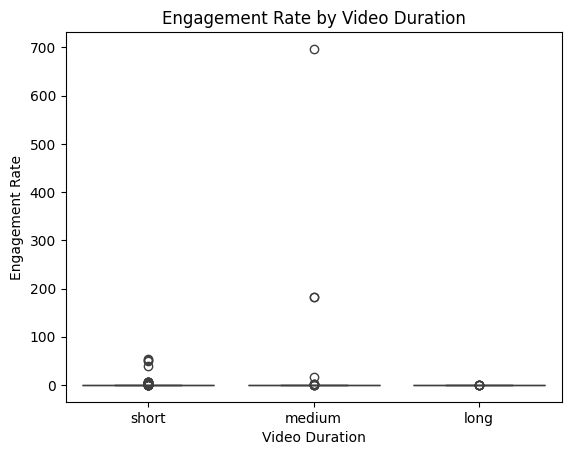

In [11]:
fig = sns.boxplot(x = 'duration_length', y = 'engagement_rate', data = youtube_clean)

plt.title('Engagement Rate by Video Duration')
plt.xlabel('Video Duration')
plt.ylabel('Engagement Rate')

plt.show()

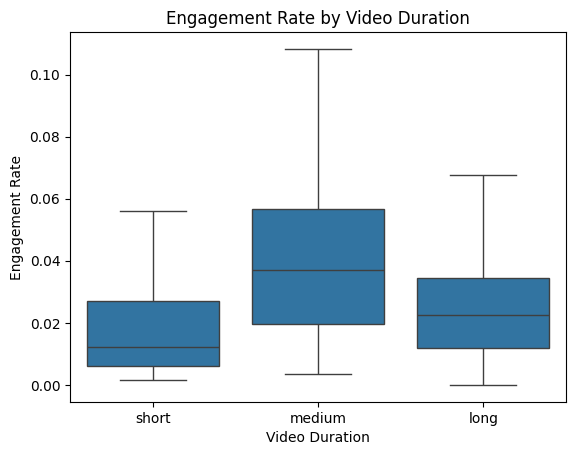

In [12]:
fig = sns.boxplot(x = 'duration_length', 
                  y = 'engagement_rate', 
                  data = youtube_clean,
                  showfliers = False)

plt.title('Engagement Rate by Video Duration')
plt.xlabel('Video Duration')
plt.ylabel('Engagement Rate')

plt.show()

In [13]:
youtube_clean['log_likes'] = np.log1p(youtube_clean["likes"])
youtube_clean['log_views'] = np.log1p(youtube_clean["views"])

youtube_clean.head()

,views,likes,comments,duration,engagement_rate,duration_length,log_likes,log_views
0,8962092.0,243350.0,515.0,57,0.027153,medium,12.402260,16.008514
1,289626.0,3393.0,1240.0,470,0.011715,long,8.129764,12.576349
2,81372201.0,4178447.0,6378.0,47,0.051350,medium,15.245450,18.214544
3,21255964.0,909386.0,2681.0,31,0.042783,medium,13.720526,16.872148
4,2790436.0,44278.0,1359.0,16,0.015868,short,10.698266,14.841709


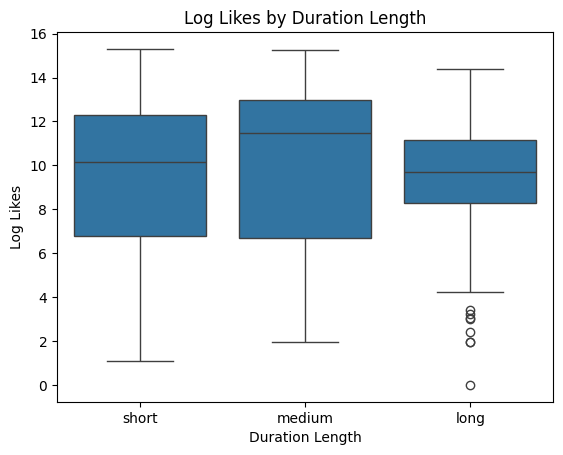

In [14]:
fig = sns.boxplot(x = 'duration_length', y = 'log_likes', data = youtube_clean)

plt.title('Log Likes by Duration Length')
plt.xlabel('Duration Length')
plt.ylabel('Log Likes')

plt.show()

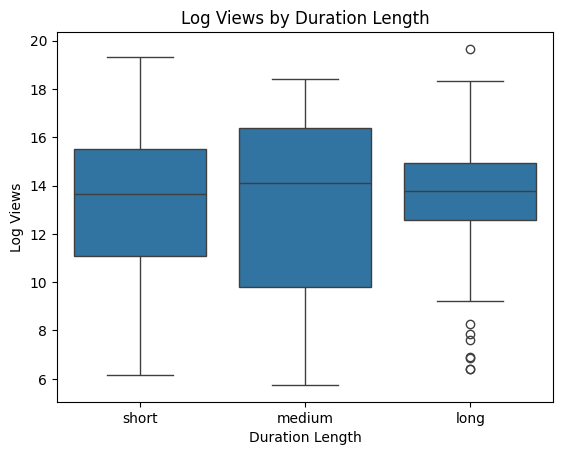

In [15]:
fig = sns.boxplot(x = 'duration_length', y = 'log_views', data = youtube_clean)

plt.title('Log Views by Duration Length')
plt.xlabel('Duration Length')
plt.ylabel('Log Views')

plt.show()

## Statistical Modeling & Analysis

### Linear regression

In [16]:
# linear regression: duration & log views
X = youtube_clean['duration']
y = youtube_clean['log_views']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_views   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.414
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0651
Time:                        22:33:51   Log-Likelihood:                -1488.5
No. Observations:                 600   AIC:                             2981.
Df Residuals:                     598   BIC:                             2990.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.2790      0.127    104.769      0.000      13.030      13.528
duration       0.0002      0.000      1.848      0.065   -1.25e-05       0.000
==============================================================================
Omnibus:                       30.598   Durbin-Watson:                   1.507
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.166
Skew:                          -0.420   Prob(JB):                     3.43e-06
Kurtosis:                       2.450   Cond. No.                     1.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Given by the summary table, the R-squared value of 0.006 means that about 0.6% of the variation in views is explained by duration in the regression model.

In [17]:
# linear regression: duration & log likes
X = youtube_clean['duration']
y = youtube_clean['log_likes']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_likes   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.05946
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.807
Time:                        22:33:51   Log-Likelihood:                -1548.9
No. Observations:                 600   AIC:                             3102.
Df Residuals:                     598   BIC:                             3111.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6263      0.140     68.674      0.000       9.351       9.902
duration   -2.904e-05      0.000     -0.244      0.807      -0.000       0.000
==============================================================================
Omnibus:                       41.528   Durbin-Watson:                   1.593
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.658
Skew:                          -0.559   Prob(JB):                     4.03e-09
Kurtosis:                       2.457   Cond. No.                     1.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared value of 0.000 means that about 0% of the variation in likes is explained by duration in the regression model.

In [18]:
# linear regression: duration & engagement rate
X = youtube_clean['duration']
y = youtube_clean['engagement_rate']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        engagement_rate   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3811
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.537
Time:                        22:33:51   Log-Likelihood:                -2902.7
No. Observations:                 600   AIC:                             5809.
Df Residuals:                     598   BIC:                             5818.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5394      1.338      1.897      0.058      -0.089       5.168
duration      -0.0007      0.001     -0.617      0.537      -0.003       0.002
==============================================================================
Omnibus:                     1403.755   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5037162.023
Skew:                          20.317   Prob(JB):                         0.00
Kurtosis:                     450.029   Cond. No.                     1.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The R-squared value of 0.001 means that about 0.1% of the variation in engagement rate is explained by duration in the regression model.

### ANOVA testing

Since our dataset compares three video duration categories&mdash;short, medium, and long&mdash;against engagement measures (log views and log likes), a one-way ANOVA is appropriate because it tests whether mean engagement differs significantly across duration groups.

For our first ANOVA test, we will be testing the two hypothesis:

- H<sub>0</sub>: Average log views are the same throughout all duration groups
- H<sub>1</sub>: At least one average is different

In [19]:
# one-way ANOVA: duration length & log views
short = youtube_clean[youtube_clean['duration_length'] == 'short']['log_views']
medium = youtube_clean[youtube_clean['duration_length'] == 'medium']['log_views']
long = youtube_clean[youtube_clean['duration_length'] == 'long']['log_views']

print('Statistic:', stats.f_oneway(short, medium, long).statistic,
      '\np-value:', stats.f_oneway(short, medium, long).pvalue)

Statistic: 0.5331780273768826 
p-value: 0.5870164623018681


A one-way ANOVA test was conducted to test whether YouTube video duration lengths (short, medium, long) differ in average log views. The analysis yielded a test statistic of F = 0.533 with p = 0.587. Since the p-value is greater than α = 0.05, we fail to reject the null hypothesis that there is no statistically significant difference in mean log views across duration lengths.

For our second ANOVA test, we will be testing the two hypothesis:

- H<sub>0</sub>: Average log likes are the same throughout all duration groups
- H<sub>1</sub>: At least one average is different

In [20]:
# one-way ANOVA: duration length & log likes
short = youtube_clean[youtube_clean['duration_length'] == 'short']['log_likes']
medium = youtube_clean[youtube_clean['duration_length'] == 'medium']['log_likes']
long = youtube_clean[youtube_clean['duration_length'] == 'long']['log_likes']

print('Statistic:', stats.f_oneway(short, medium, long).statistic,
      '\np-value:', stats.f_oneway(short, medium, long).pvalue)

Statistic: 2.0322612043618946 
p-value: 0.13194443678127654


Another one-way ANOVA test was conducted to test whether YouTube video duration lengths (short, medium, long) differ in average log likes. The analysis yielded a test statistic of F = 2.032 with p = 0.132. Since the p-value is greater than α = 0.05, we fail to reject the null hypothesis that there is no statistically significant difference in mean log likes across duration lengths.

## Analysis Summary

Based on our results, the duration of a YouTube video cannot meaningfully predict the likes or views it receives. After conducting 2 one-way ANOVA tests, each with a significance level of α = 0.05, we have also found there to be no statistically significant difference between average log views and different duration lengths&mdash;short, medium, long&mdash;nor average log likes and different duration lengths.